# RNI Group 2 — Data Understanding, Preparation and Exploratory Data Analysis

## Project
Investigating the impact and influence of an automated RFM-based customer
segmentation and analytics system on retention decision making among online
retail businesses.

## CRISP-DM Phase
Data Understanding → Data Preparation → Exploratory Data Analysis

## Dataset
Online Retail II — UCI Machine Learning Repository

This notebook documents the structure, quality, preparation and exploratory
characteristics of the Online Retail II dataset before customer segmentation
and predictive modelling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
file_path = "../data/raw/online_retail_II.xlsx"

In [3]:
xls = pd.ExcelFile(file_path)

print("Workbook sheets:")
print(xls.sheet_names)

Workbook sheets:
['Year 2009-2010', 'Year 2010-2011']


In [4]:
df_2009_2010 = pd.read_excel(
    file_path,
    sheet_name=0
)

df_2010_2011 = pd.read_excel(
    file_path,
    sheet_name=1
)

In [5]:
print("2009-2010 shape:", df_2009_2010.shape)
print("2010-2011 shape:", df_2010_2011.shape)

2009-2010 shape: (525461, 8)
2010-2011 shape: (541910, 8)


In [6]:
df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

print("Combined dataset shape:", df.shape)

Combined dataset shape: (1067371, 8)


In [7]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


In [8]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,"12,680.00",France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,"12,680.00",France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,"12,680.00",France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,"12,680.00",France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,"12,680.00",France


In [9]:
df.sample(5, random_state=42)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
455941,532657,21314,SMALL GLASS HEART TRINKET POT,12,2010-11-14 11:10:00,2.10,"14,562.00",United Kingdom
826291,563214,22383,LUNCH BAG SUKI DESIGN,2,2011-08-14 12:56:00,1.65,"16,370.00",United Kingdom
191636,507597,22561,WOODEN SCHOOL COLOURING SET,12,2010-05-10 13:21:00,1.65,"17,700.00",United Kingdom
25864,491634,21588,RETRO SPOT GIANT TUBE MATCHES,1,2009-12-11 15:40:00,2.55,"17,841.00",United Kingdom
73233,496007,85232B,SET/3 RUSSIAN DOLL STACKING TINS,3,2010-01-28 12:32:00,4.95,"15,203.00",United Kingdom


In [10]:
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 1067371
Number of columns: 8


In [11]:
data_dictionary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isna().sum().values,
    "Missing %": (df.isna().mean() * 100).round(2).values,
    "Unique Values": df.nunique().values
})

data_dictionary

,Column,Data Type,Missing Values,Missing %,Unique Values
0,Invoice,object,0,0.00,53628
1,StockCode,object,0,0.00,5305
2,Description,object,4382,0.41,5698
3,Quantity,int64,0,0.00,1057
4,InvoiceDate,datetime64[ns],0,0.00,47635
5,Price,float64,0,0.00,2807
6,Customer ID,float64,243007,22.77,5942
7,Country,object,0,0.00,43


In [12]:
variable_roles = pd.DataFrame({
    "Variable": [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "Price",
        "Customer ID",
        "Country"
    ],
    "Role": [
        "Transaction identifier",
        "Product identifier",
        "Product attribute",
        "Transaction measure",
        "Temporal attribute",
        "Transaction measure",
        "Customer identifier",
        "Geographic attribute"
    ]
})

variable_roles

,Variable,Role
0,Invoice,Transaction identifier
1,StockCode,Product identifier
2,Description,Product attribute
3,Quantity,Transaction measure
4,InvoiceDate,Temporal attribute
5,Price,Transaction measure
6,Customer ID,Customer identifier
7,Country,Geographic attribute


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [14]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

missing_pct = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_pct.round(2)
})

missing_report

,Missing Count,Missing Percentage
Customer ID,243007,22.77
Description,4382,0.41
Invoice,0,0.00
StockCode,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Country,0,0.00


In [15]:
identified = df["Customer ID"].notna().sum()
unidentified = df["Customer ID"].isna().sum()

print("Records with Customer ID:", identified)
print("Records without Customer ID:", unidentified)
print(
    "Percentage identifiable:",
    round(identified / len(df) * 100, 2),
    "%"
)

Records with Customer ID: 824364
Records without Customer ID: 243007
Percentage identifiable: 77.23 %


In [16]:
df["Invoice"] = df["Invoice"].astype(str)

df["IsCancellation"] = (
    df["Invoice"]
    .str.upper()
    .str.startswith("C")
)

In [17]:
df["IsCancellation"].value_counts()

IsCancellation
False    1047877
True       19494
Name: count, dtype: int64

In [18]:
cancellation_summary = pd.DataFrame({
    "Records": df["IsCancellation"].value_counts(),
    "Percentage": (
        df["IsCancellation"]
        .value_counts(normalize=True) * 100
    ).round(2)
})

cancellation_summary

,Records,Percentage
IsCancellation,,
False,1047877,98.17
True,19494,1.83


In [19]:
df["Quantity"].describe()

count   1,067,371.00
mean            9.94
std           172.71
min       -80,995.00
25%             1.00
50%             3.00
75%            10.00
max        80,995.00
Name: Quantity, dtype: float64

In [20]:
print("Negative quantities:", (df["Quantity"] < 0).sum())
print("Zero quantities:", (df["Quantity"] == 0).sum())
print("Positive quantities:", (df["Quantity"] > 0).sum())

Negative quantities: 22950
Zero quantities: 0
Positive quantities: 1044421


In [21]:
df["Price"].describe()

count   1,067,371.00
mean            4.65
std           123.55
min       -53,594.36
25%             1.25
50%             2.10
75%             4.15
max        38,970.00
Name: Price, dtype: float64

In [22]:
price_quality = pd.Series({
    "Negative prices": (df["Price"] < 0).sum(),
    "Zero prices": (df["Price"] == 0).sum(),
    "Positive prices": (df["Price"] > 0).sum()
})

price_quality

Negative prices          5
Zero prices           6202
Positive prices    1061164
dtype: int64

In [23]:
df[df["Price"] <= 0].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancellation
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom,False
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom,False
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom,False
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom,False
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.00,NaN,United Kingdom,False
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.00,NaN,United Kingdom,False
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.00,NaN,United Kingdom,False
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.00,NaN,United Kingdom,False
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.00,NaN,United Kingdom,False
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.00,NaN,United Kingdom,False


In [24]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print(
    "Duplicate percentage:",
    round(duplicate_count / len(df) * 100, 2),
    "%"
)

Duplicate rows: 34335
Duplicate percentage: 3.22 %


In [25]:
df[df.duplicated(keep=False)].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancellation
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,"16,329.00",United Kingdom,False
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,"16,329.00",United Kingdom,False
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom,False
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,"16,329.00",United Kingdom,False
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,"16,329.00",United Kingdom,False
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False


In [26]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

print("Missing dates:", df["InvoiceDate"].isna().sum())
print("Minimum date:", df["InvoiceDate"].min())
print("Maximum date:", df["InvoiceDate"].max())

Missing dates: 0
Minimum date: 2009-12-01 07:45:00
Maximum date: 2011-12-09 12:50:00


In [27]:
df["Revenue"] = (
    df["Quantity"] *
    df["Price"]
)

In [28]:
df["Revenue"].describe()

count   1,067,371.00
mean           18.07
std           292.42
min      -168,469.60
25%             3.75
50%             9.90
75%            17.70
max       168,469.60
Name: Revenue, dtype: float64

In [29]:
print("Total recorded revenue:", df["Revenue"].sum())

Total recorded revenue: 19287250.568


In [30]:
df["Revenue"].describe()

count   1,067,371.00
mean           18.07
std           292.42
min      -168,469.60
25%             3.75
50%             9.90
75%            17.70
max       168,469.60
Name: Revenue, dtype: float64

In [31]:
print("Unique customers:", df["Customer ID"].nunique())
print("Unique invoices:", df["Invoice"].nunique())
print("Unique products:", df["StockCode"].nunique())
print("Unique countries:", df["Country"].nunique())

Unique customers: 5942
Unique invoices: 53628
Unique products: 5305
Unique countries: 43


In [32]:
customer_orders = (
    df.dropna(subset=["Customer ID"])
      .groupby("Customer ID")["Invoice"]
      .nunique()
)

customer_orders.describe()

count   5,942.00
mean        7.55
std        15.97
min         1.00
25%         2.00
50%         4.00
75%         8.00
max       510.00
Name: Invoice, dtype: float64

In [33]:
df_raw = df.copy()

In [34]:
df_prepared = df_raw.drop_duplicates().copy()

print("Rows before:", len(df_raw))
print("Rows after:", len(df_prepared))
print("Rows removed:", len(df_raw) - len(df_prepared))

Rows before: 1067371
Rows after: 1033036
Rows removed: 34335


In [35]:
print(
    "Duplicate percentage removed:",
    round(
        (len(df_raw) - len(df_prepared))
        / len(df_raw) * 100,
        2
    ),
    "%"
)

Duplicate percentage removed: 3.22 %


In [36]:
df_prepared["Invoice"] = (
    df_prepared["Invoice"]
    .astype(str)
    .str.strip()
)

df_prepared["StockCode"] = (
    df_prepared["StockCode"]
    .astype(str)
    .str.strip()
)

df_prepared["Country"] = (
    df_prepared["Country"]
    .astype(str)
    .str.strip()
)

df_prepared["Description"] = (
    df_prepared["Description"]
    .astype("string")
    .str.strip()
)

df_prepared["InvoiceDate"] = pd.to_datetime(
    df_prepared["InvoiceDate"],
    errors="coerce"
)

df_prepared["Quantity"] = pd.to_numeric(
    df_prepared["Quantity"],
    errors="coerce"
)

df_prepared["Price"] = pd.to_numeric(
    df_prepared["Price"],
    errors="coerce"
)

df_prepared["Customer ID"] = pd.to_numeric(
    df_prepared["Customer ID"],
    errors="coerce"
)

In [37]:
df_prepared["IsCancellation"] = (
    df_prepared["Invoice"]
    .str.upper()
    .str.startswith("C")
)

In [38]:
validation_report = pd.DataFrame({
    "Check": [
        "Total records",
        "Missing Customer IDs",
        "Missing descriptions",
        "Exact duplicate records",
        "Cancellation records",
        "Negative quantities",
        "Zero quantities",
        "Negative prices",
        "Zero prices",
        "Invalid dates"
    ],
    "Count": [
        len(df_prepared),
        df_prepared["Customer ID"].isna().sum(),
        df_prepared["Description"].isna().sum(),
        df_prepared.duplicated().sum(),
        df_prepared["IsCancellation"].sum(),
        (df_prepared["Quantity"] < 0).sum(),
        (df_prepared["Quantity"] == 0).sum(),
        (df_prepared["Price"] < 0).sum(),
        (df_prepared["Price"] == 0).sum(),
        df_prepared["InvoiceDate"].isna().sum()
    ]
})

validation_report

,Check,Count
0,Total records,1033036
1,Missing Customer IDs,235151
2,Missing descriptions,4275
3,Exact duplicate records,0
4,Cancellation records,19104
5,Negative quantities,22496
6,Zero quantities,0
7,Negative prices,5
8,Zero prices,6014
9,Invalid dates,0


In [39]:
transaction_df = df_prepared[
    (~df_prepared["IsCancellation"]) &
    (df_prepared["Quantity"] > 0) &
    (df_prepared["Price"] > 0)
].copy()

In [40]:
transaction_df["Revenue"] = (
    transaction_df["Quantity"] *
    transaction_df["Price"]
)

In [41]:
print("Raw/prepared records:", len(df_prepared))
print("Qualifying sales records:", len(transaction_df))
print(
    "Records excluded:",
    len(df_prepared) - len(transaction_df)
)

Raw/prepared records: 1033036
Qualifying sales records: 1007913
Records excluded: 25123


In [42]:
customer_df = transaction_df[
    transaction_df["Customer ID"].notna()
].copy()

In [43]:
print("Customer-level records:", len(customer_df))
print(
    "Unique identifiable customers:",
    customer_df["Customer ID"].nunique()
)

Customer-level records: 779425
Unique identifiable customers: 5878


In [44]:
transaction_df["Year"] = (
    transaction_df["InvoiceDate"].dt.year
)

transaction_df["Month"] = (
    transaction_df["InvoiceDate"].dt.month
)

transaction_df["MonthName"] = (
    transaction_df["InvoiceDate"].dt.month_name()
)

transaction_df["Quarter"] = (
    transaction_df["InvoiceDate"].dt.quarter
)

transaction_df["Day"] = (
    transaction_df["InvoiceDate"].dt.day
)

transaction_df["DayOfWeek"] = (
    transaction_df["InvoiceDate"].dt.day_name()
)

transaction_df["Hour"] = (
    transaction_df["InvoiceDate"].dt.hour
)

In [45]:
invoice_df = (
    transaction_df
    .groupby(
        ["Invoice", "Customer ID", "InvoiceDate", "Country"],
        as_index=False
    )
    .agg(
        Quantity=("Quantity", "sum"),
        Revenue=("Revenue", "sum"),
        UniqueProducts=("StockCode", "nunique"),
        LineItems=("StockCode", "count")
    )
)

In [46]:
invoice_df.head()

,Invoice,Customer ID,InvoiceDate,Country,Quantity,Revenue,UniqueProducts,LineItems
0,489434,"13,085.00",2009-12-01 07:45:00,United Kingdom,166,505.30,8,8
1,489435,"13,085.00",2009-12-01 07:46:00,United Kingdom,60,145.80,4,4
2,489436,"13,078.00",2009-12-01 09:06:00,United Kingdom,193,630.33,19,19
3,489437,"15,362.00",2009-12-01 09:08:00,United Kingdom,145,310.75,23,23
4,489438,"18,102.00",2009-12-01 09:24:00,United Kingdom,826,"2,286.24",17,17


In [47]:
invoice_df.shape

(37033, 8)

In [48]:
customer_summary = (
    invoice_df
    .groupby("Customer ID")
    .agg(
        Orders=("Invoice", "nunique"),
        TotalQuantity=("Quantity", "sum"),
        TotalRevenue=("Revenue", "sum"),
        AverageOrderValue=("Revenue", "mean"),
        UniqueProducts=("UniqueProducts", "sum"),
        FirstPurchase=("InvoiceDate", "min"),
        LastPurchase=("InvoiceDate", "max")
    )
    .reset_index()
)

In [49]:
customer_summary.head()

,Customer ID,Orders,TotalQuantity,TotalRevenue,AverageOrderValue,UniqueProducts,FirstPurchase,LastPurchase
0,"12,346.00",12,74285,"77,556.46","6,463.04",34,2009-12-14 08:34:00,2011-01-18 10:01:00
1,"12,347.00",8,2967,"4,921.53",615.19,222,2010-10-31 14:20:00,2011-12-07 15:52:00
2,"12,348.00",5,2714,"2,019.40",403.88,47,2010-09-27 14:59:00,2011-09-25 13:13:00
3,"12,349.00",4,1624,"4,428.69","1,107.17",175,2010-04-29 13:20:00,2011-11-21 09:51:00
4,"12,350.00",1,197,334.40,334.40,17,2011-02-02 16:01:00,2011-02-02 16:01:00


C1 Overall transaction performance
C2 Time behaviour
C3 Customer behaviour
C4 Product behaviour
C5 Geographic behaviour
C6 Transaction/basket behaviour
C7 Data-quality behaviour
C8 Purchase intervals
C9 EDA conclusions

In [50]:
eda_kpis = {
    "Transactions": transaction_df["Invoice"].nunique(),
    "Customers": transaction_df["Customer ID"].nunique(),
    "Products": transaction_df["StockCode"].nunique(),
    "Countries": transaction_df["Country"].nunique(),
    "Units Sold": transaction_df["Quantity"].sum(),
    "Revenue": transaction_df["Revenue"].sum(),
    "Average Order Value": invoice_df["Revenue"].mean()
}

eda_kpis

{'Transactions': 40077,
 'Customers': 5878,
 'Products': 4916,
 'Countries': 43,
 'Units Sold': np.int64(11205148),
 'Revenue': np.float64(20476260.448),
 'Average Order Value': np.float64(469.17085485917966)}

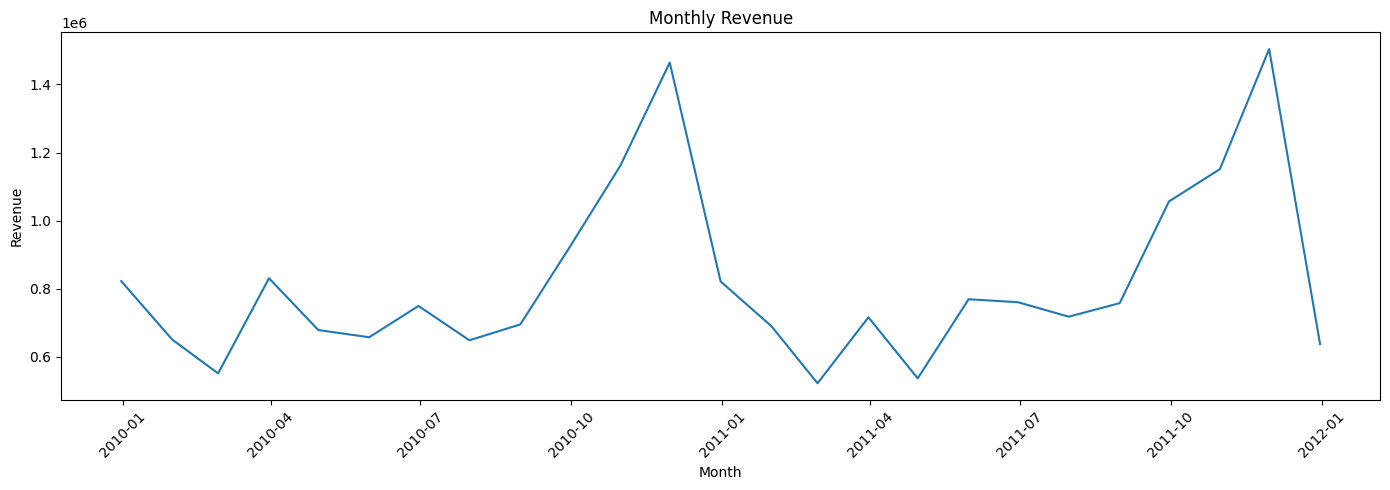

In [51]:
monthly_revenue = (
    transaction_df
    .set_index("InvoiceDate")
    .resample("ME")["Revenue"]
    .sum()
)

plt.figure(figsize=(14, 5))
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

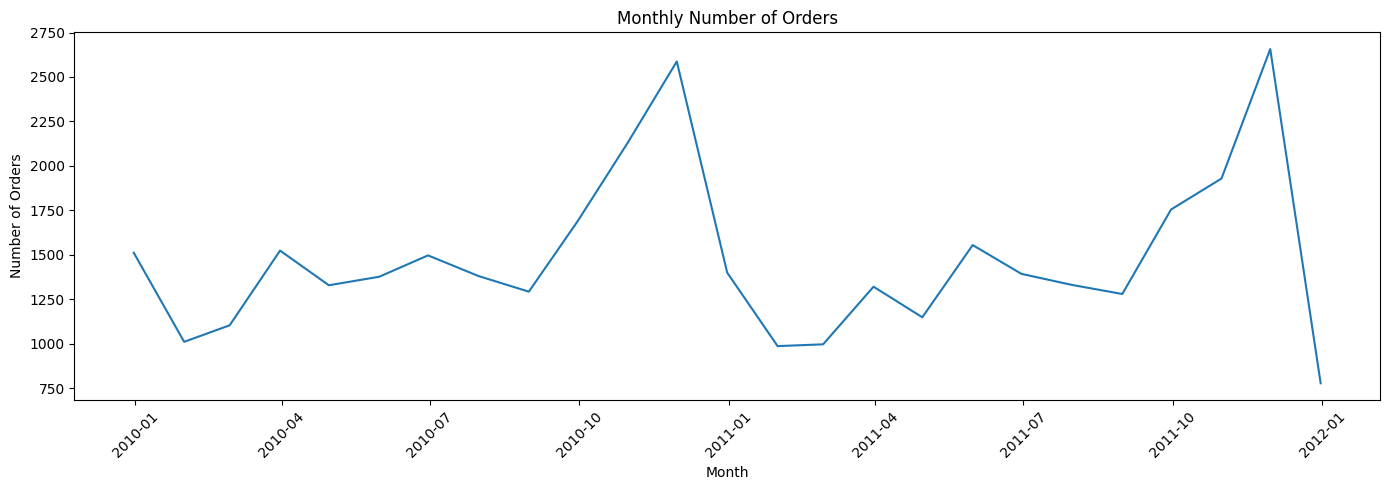

In [52]:
monthly_orders = (
    invoice_df
    .set_index("InvoiceDate")
    .resample("ME")["Invoice"]
    .nunique()
)

plt.figure(figsize=(14, 5))
plt.plot(
    monthly_orders.index,
    monthly_orders.values
)

plt.title("Monthly Number of Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

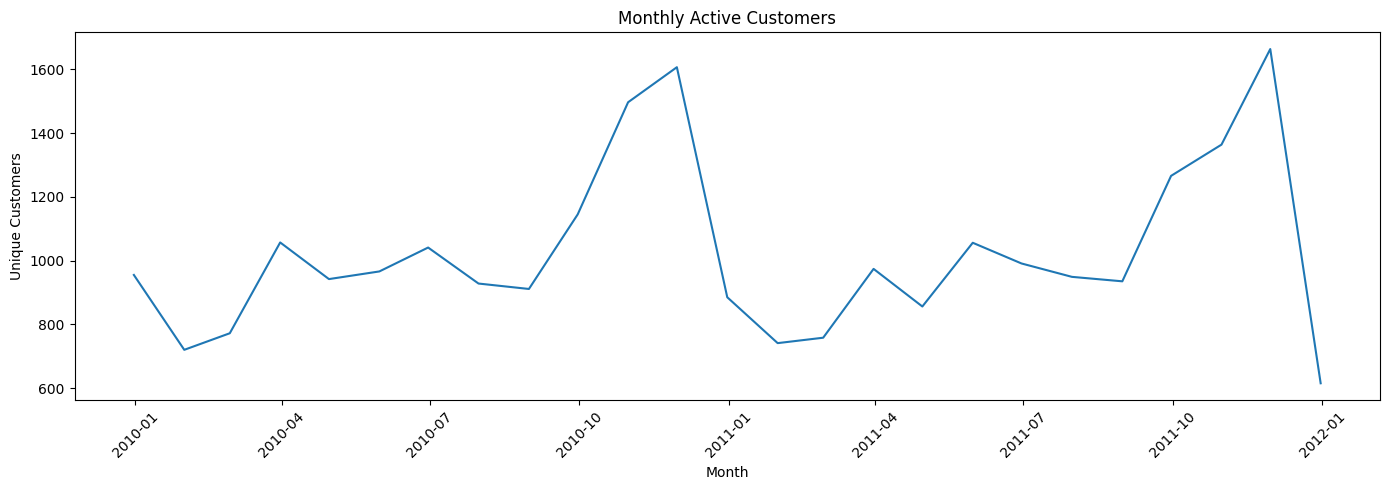

In [53]:
monthly_customers = (
    transaction_df
    .set_index("InvoiceDate")
    .resample("ME")["Customer ID"]
    .nunique()
)

plt.figure(figsize=(14, 5))
plt.plot(
    monthly_customers.index,
    monthly_customers.values
)

plt.title("Monthly Active Customers")
plt.xlabel("Month")
plt.ylabel("Unique Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [54]:
yearly_revenue = (
    transaction_df
    .groupby("Year")["Revenue"]
    .sum()
)

yearly_revenue

Year
2009     822,483.95
2010   9,833,100.42
2011   9,820,676.07
Name: Revenue, dtype: float64

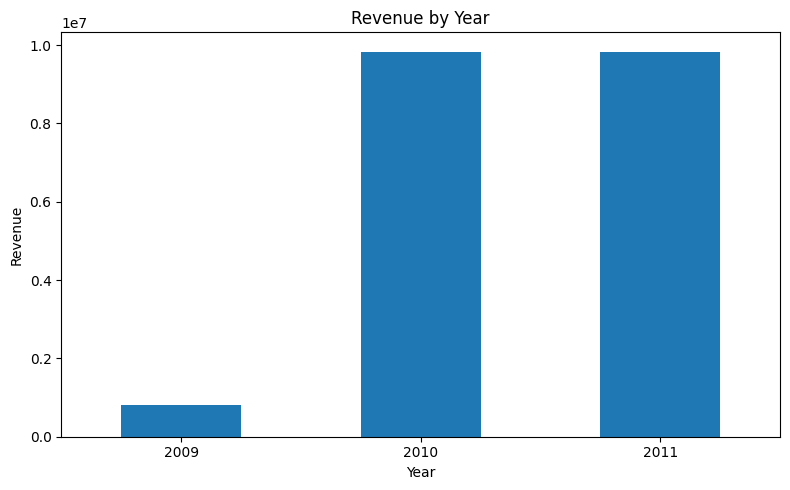

In [55]:
plt.figure(figsize=(8, 5))
yearly_revenue.plot(kind="bar")

plt.title("Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [56]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_revenue = (
    transaction_df
    .groupby("DayOfWeek")["Revenue"]
    .sum()
    .reindex(weekday_order)
)

weekday_revenue

DayOfWeek
Monday      3,581,594.18
Tuesday     4,078,149.96
Wednesday   3,488,444.33
Thursday    4,195,212.76
Friday      3,323,908.88
Saturday        9,803.05
Sunday      1,799,147.28
Name: Revenue, dtype: float64

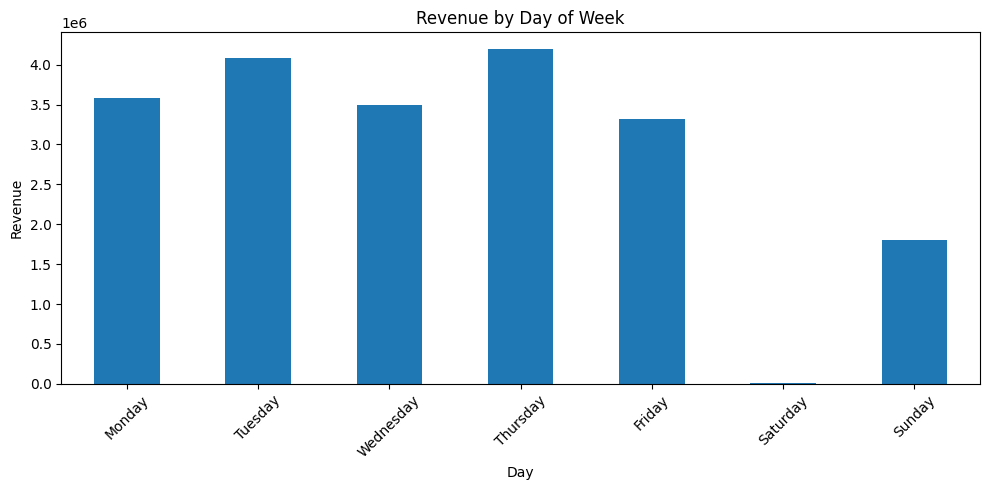

In [57]:
plt.figure(figsize=(10, 5))
weekday_revenue.plot(kind="bar")

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

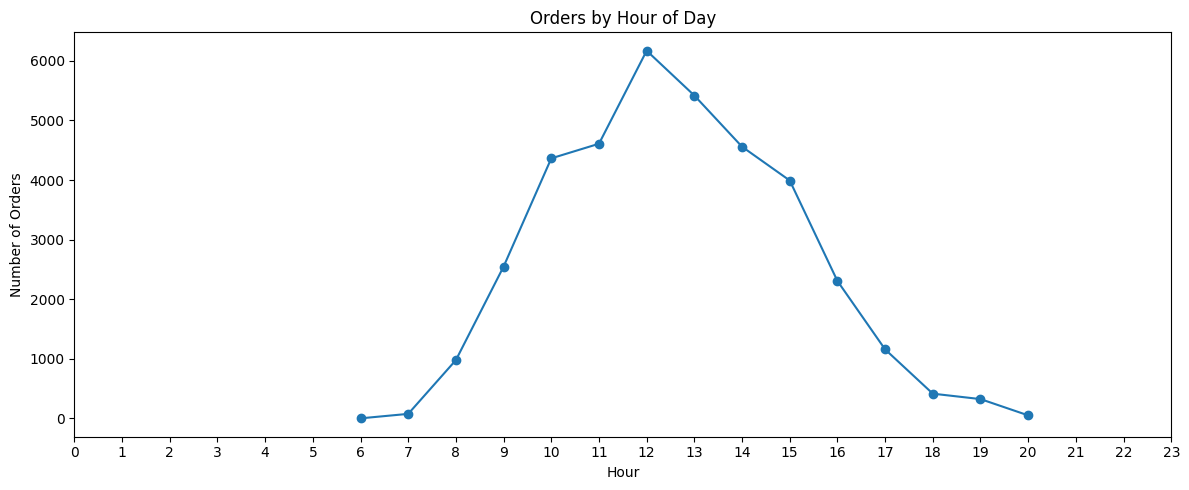

In [58]:
hourly_orders = (
    invoice_df
    .assign(Hour=invoice_df["InvoiceDate"].dt.hour)
    .groupby("Hour")["Invoice"]
    .nunique()
)

plt.figure(figsize=(12, 5))
plt.plot(
    hourly_orders.index,
    hourly_orders.values,
    marker="o"
)

plt.title("Orders by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [59]:
customer_orders = (
    invoice_df
    .groupby("Customer ID")["Invoice"]
    .nunique()
)

customer_orders.describe()

count   5,878.00
mean        6.29
std        13.01
min         1.00
25%         1.00
50%         3.00
75%         7.00
max       398.00
Name: Invoice, dtype: float64

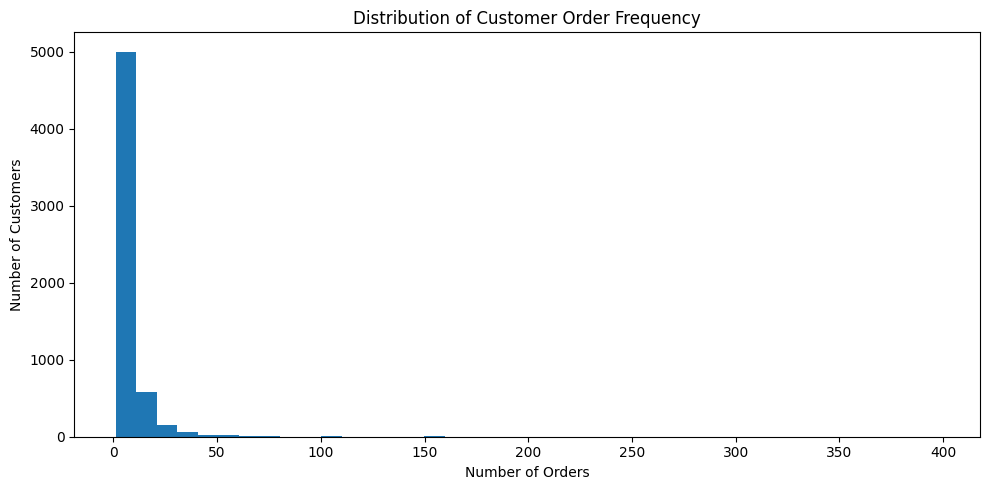

In [60]:
plt.figure(figsize=(10, 5))

plt.hist(
    customer_orders,
    bins=40
)

plt.title("Distribution of Customer Order Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [61]:
customer_orders.sort_values(
    ascending=False
).head(20)

Customer ID
14,911.00    398
12,748.00    336
17,841.00    211
15,311.00    208
13,089.00    203
14,606.00    192
14,156.00    156
17,850.00    155
14,646.00    151
18,102.00    145
13,694.00    143
15,061.00    127
14,527.00    122
17,949.00    118
12,971.00    116
13,798.00    110
16,422.00    109
16,029.00    107
13,408.00    106
17,961.00    100
Name: Invoice, dtype: int64

In [62]:
top_customers = (
    customer_summary
    .sort_values(
        "TotalRevenue",
        ascending=False
    )
    .head(20)
)

top_customers[
    [
        "Customer ID",
        "Orders",
        "TotalRevenue",
        "AverageOrderValue"
    ]
]

,Customer ID,Orders,TotalRevenue,AverageOrderValue
5692,"18,102.00",145,"580,987.04","4,006.81"
2277,"14,646.00",151,"528,602.52","3,500.68"
1789,"14,156.00",156,"313,437.62","2,009.22"
2538,"14,911.00",398,"291,420.81",728.55
5050,"17,450.00",51,"244,784.25","4,799.69"
1331,"13,694.00",143,"195,640.69","1,368.12"
5109,"17,511.00",60,"172,132.87","2,821.85"
4061,"16,446.00",2,"168,472.50","84,236.25"
4295,"16,684.00",55,"147,142.77","2,675.32"
68,"12,415.00",28,"144,458.37","5,159.23"


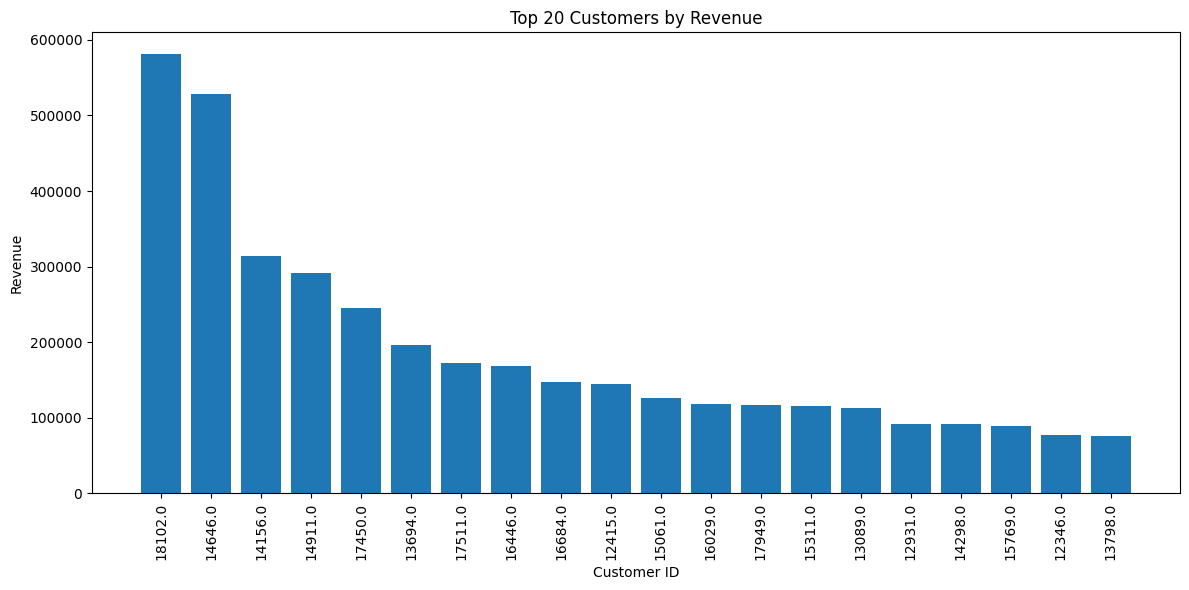

In [63]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_customers["Customer ID"].astype(str),
    top_customers["TotalRevenue"]
)

plt.title("Top 20 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [64]:
customer_revenue = (
    customer_summary[
        ["Customer ID", "TotalRevenue"]
    ]
    .sort_values(
        "TotalRevenue",
        ascending=False
    )
    .reset_index(drop=True)
)

customer_revenue["CumulativeRevenue"] = (
    customer_revenue["TotalRevenue"].cumsum()
)

customer_revenue["CumulativeRevenuePct"] = (
    customer_revenue["CumulativeRevenue"]
    / customer_revenue["TotalRevenue"].sum()
    * 100
)

customer_revenue["CustomerRankPct"] = (
    (customer_revenue.index + 1)
    / len(customer_revenue)
    * 100
)

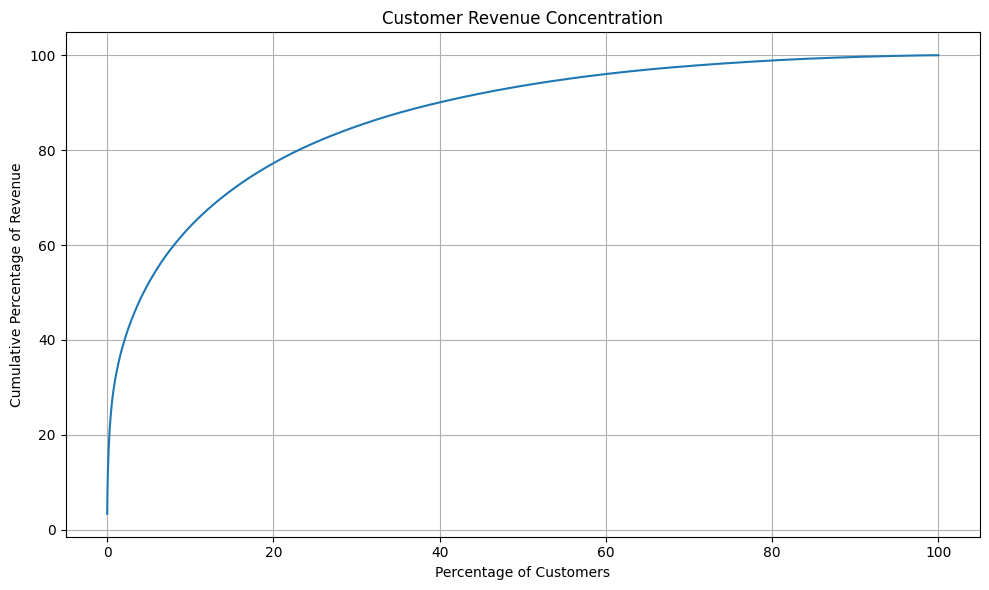

In [65]:
plt.figure(figsize=(10, 6))

plt.plot(
    customer_revenue["CustomerRankPct"],
    customer_revenue["CumulativeRevenuePct"]
)

plt.title("Customer Revenue Concentration")
plt.xlabel("Percentage of Customers")
plt.ylabel("Cumulative Percentage of Revenue")

plt.grid(True)
plt.tight_layout()
plt.show()

In [66]:
product_summary = (
    transaction_df
    .groupby(
        ["StockCode", "Description"],
        dropna=False
    )
    .agg(
        QuantitySold=("Quantity", "sum"),
        Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("Customer ID", "nunique")
    )
    .reset_index()
)

In [67]:
top_products = (
    product_summary
    .sort_values(
        "Revenue",
        ascending=False
    )
    .head(20)
)

top_products

,StockCode,Description,QuantitySold,Revenue,Orders,Customers
5585,M,Manual,9629,"339,226.24",784,438
1875,22423,REGENCY CAKESTAND 3 TIER,26478,"330,590.32",3918,1314
5584,DOT,DOTCOM POSTAGE,1415,"309,854.11",1415,1
4970,85123A,WHITE HANGING HEART T-LIGHT HOLDER,94142,"257,546.20",5356,1490
3335,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,"168,469.60",1,1
3694,47566,PARTY BUNTING,28200,"148,318.28",2674,894
4939,85099B,JUMBO BAG RED RETROSPOT,77280,"145,961.83",3245,860
4612,84879,ASSORTED COLOUR BIRD ORNAMENT,80082,"129,324.49",2807,1010
5587,POST,POSTAGE,5363,"125,682.42",1851,405
1465,22086,PAPER CHAIN KIT 50'S CHRISTMAS,35084,"117,760.29",2018,896


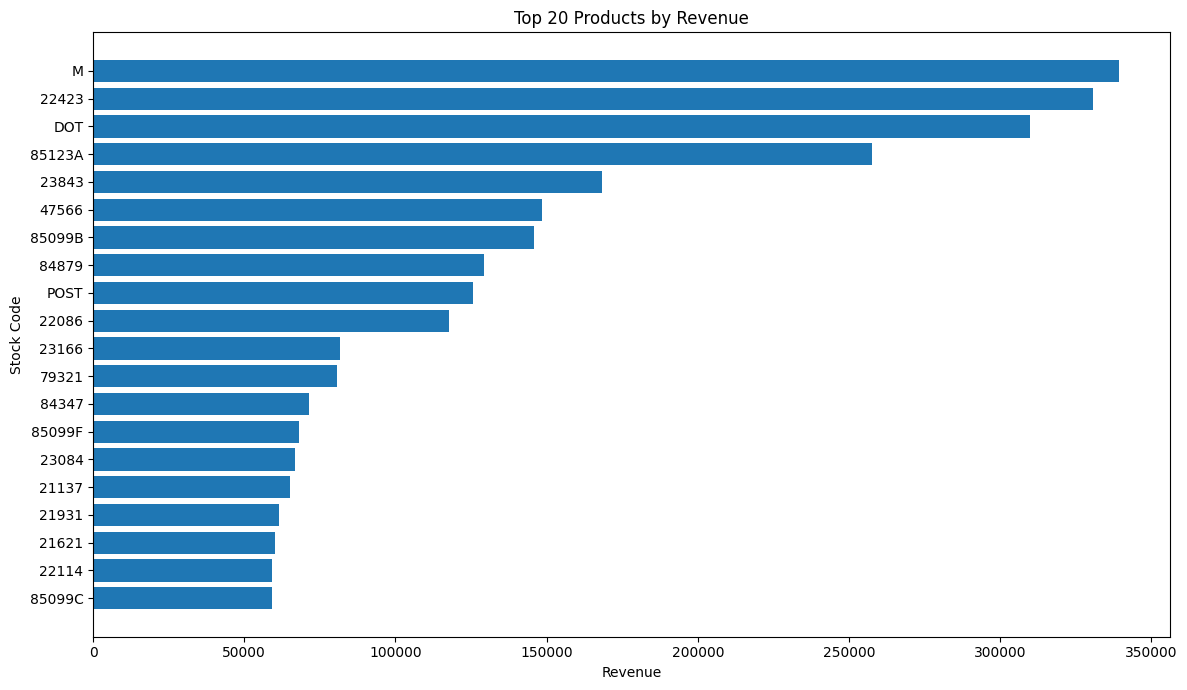

In [68]:
plt.figure(figsize=(12, 7))

plt.barh(
    top_products["StockCode"].astype(str),
    top_products["Revenue"]
)

plt.title("Top 20 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Stock Code")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [69]:
top_quantity_products = (
    product_summary
    .sort_values(
        "QuantitySold",
        ascending=False
    )
    .head(20)
)

top_quantity_products

,StockCode,Description,QuantitySold,Revenue,Orders,Customers
4145,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,106139,"24,445.61",1019,482
4970,85123A,WHITE HANGING HEART T-LIGHT HOLDER,94142,"257,546.20",5356,1490
3335,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,"168,469.60",1,1
4612,84879,ASSORTED COLOUR BIRD ORNAMENT,80082,"129,324.49",2807,1010
2790,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,"81,700.92",247,138
4939,85099B,JUMBO BAG RED RETROSPOT,77280,"145,961.83",3245,860
120,17003,BROCADE RING PURSE,70369,"14,766.42",456,215
1374,21977,PACK OF 60 PINK PAISLEY CAKE CASES,56061,"28,081.73",1993,767
4773,84991,60 TEATIME FAIRY CAKE CASES,54028,"27,041.21",2127,822
1593,22197,SMALL POPCORN HOLDER,48561,"42,699.89",1407,426


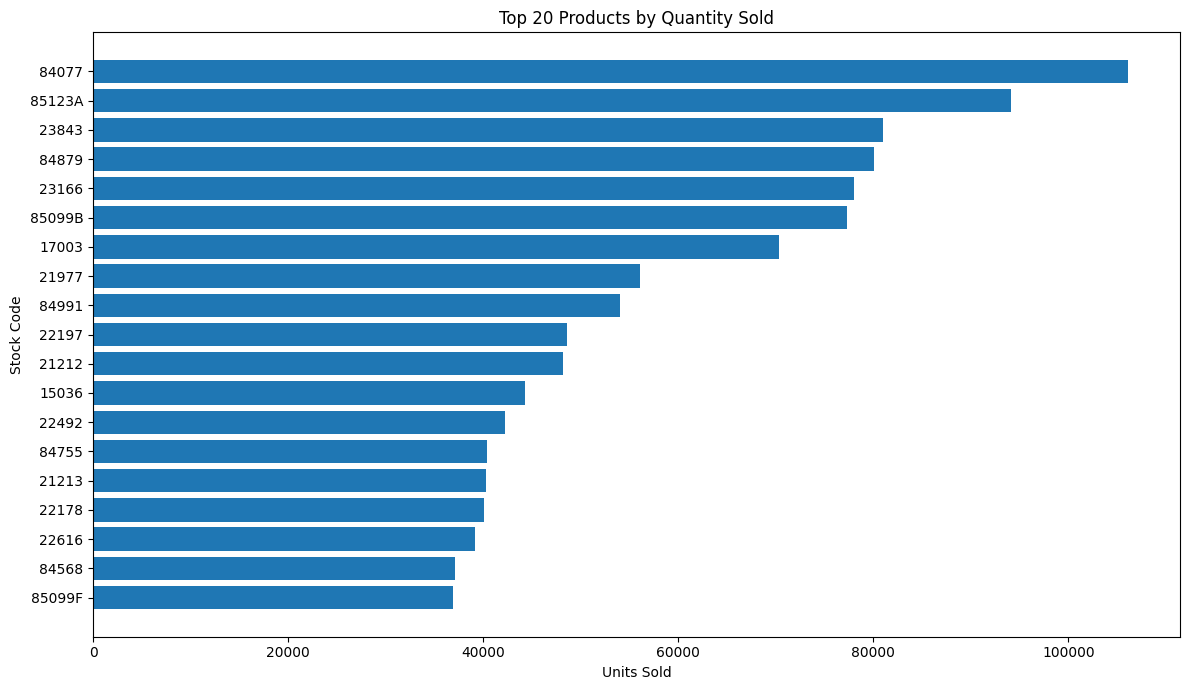

In [70]:
plt.figure(figsize=(12, 7))

plt.barh(
    top_quantity_products["StockCode"].astype(str),
    top_quantity_products["QuantitySold"]
)

plt.title("Top 20 Products by Quantity Sold")
plt.xlabel("Units Sold")
plt.ylabel("Stock Code")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [71]:
country_summary = (
    transaction_df
    .groupby("Country")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("Customer ID", "nunique"),
        Units=("Quantity", "sum")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)

country_summary.head(15)

,Revenue,Orders,Customers,Units
Country,,,,
United Kingdom,"17,410,196.12",36535,5350,9187753
EIRE,"658,767.31",626,5,336329
Netherlands,"554,038.09",228,22,383879
Germany,"425,019.71",789,107,225154
France,"350,456.09",622,95,271901
Australia,"169,283.46",95,15,103759
Spain,"108,332.49",154,41,50307
Switzerland,"100,685.59",93,22,52762
Sweden,"91,869.82",105,19,88633


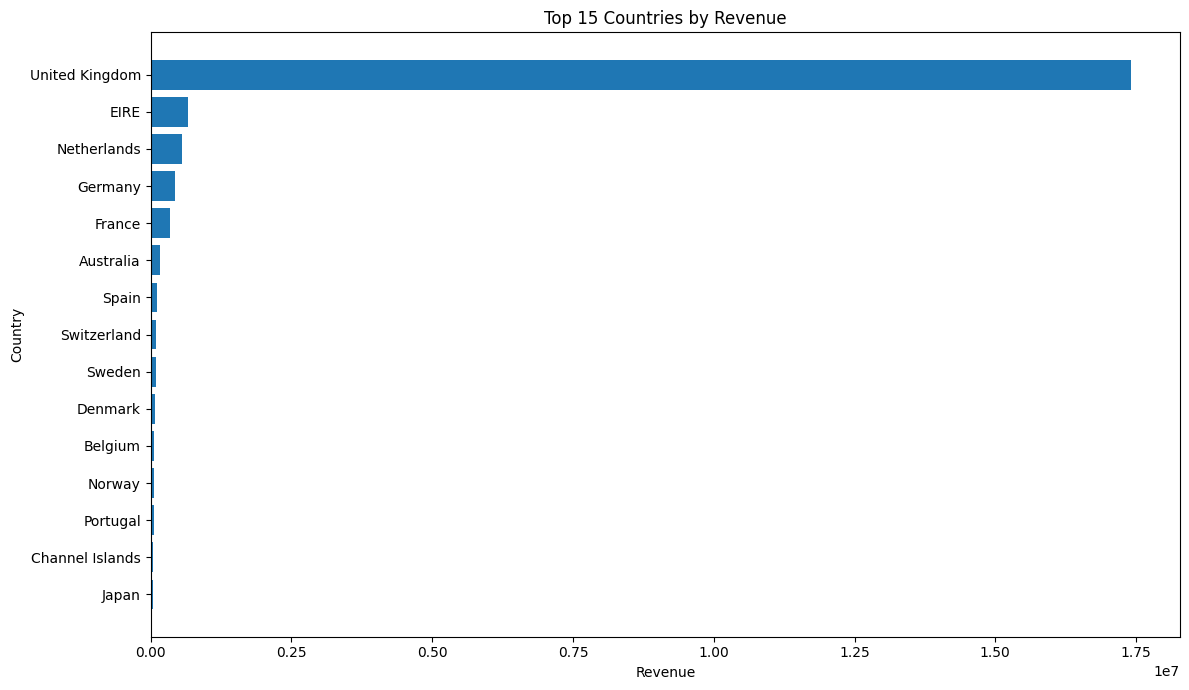

In [72]:
top_countries = country_summary.head(15)

plt.figure(figsize=(12, 7))

plt.barh(
    top_countries.index,
    top_countries["Revenue"]
)

plt.title("Top 15 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [73]:
invoice_basket = invoice_df["Quantity"]

invoice_basket.describe()

count   37,033.00
mean       283.91
std      1,231.29
min          1.00
25%         72.00
50%        151.00
75%        287.00
max     87,167.00
Name: Quantity, dtype: float64

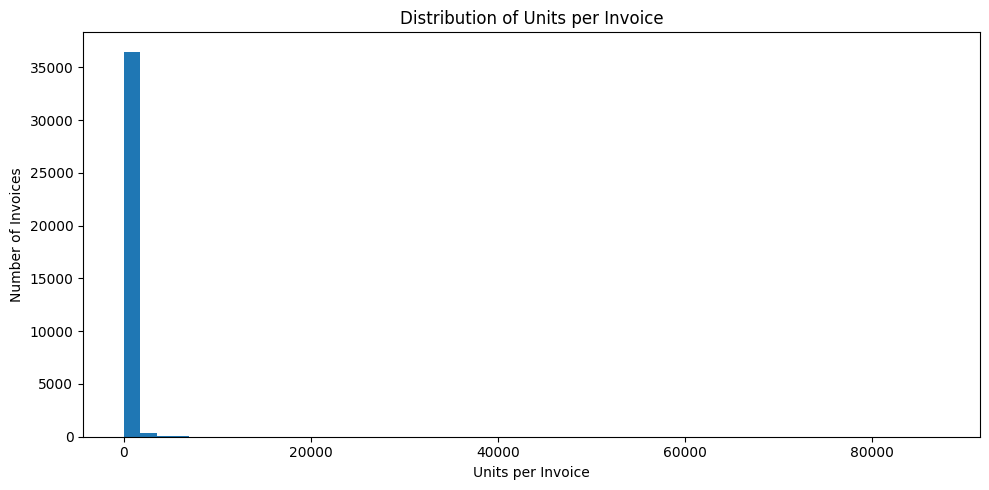

In [74]:
plt.figure(figsize=(10, 5))

plt.hist(
    invoice_basket,
    bins=50
)

plt.title("Distribution of Units per Invoice")
plt.xlabel("Units per Invoice")
plt.ylabel("Number of Invoices")

plt.tight_layout()
plt.show()

In [75]:
invoice_basket.quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
)

0.50     151.00
0.75     287.00
0.90     512.00
0.95     774.00
0.99   2,249.36
Name: Quantity, dtype: float64

In [76]:
aov = invoice_df["Revenue"]

aov.describe()

count    37,033.00
mean        469.17
std       1,358.55
min           0.38
25%         157.47
50%         302.80
75%         476.80
max     168,469.60
Name: Revenue, dtype: float64

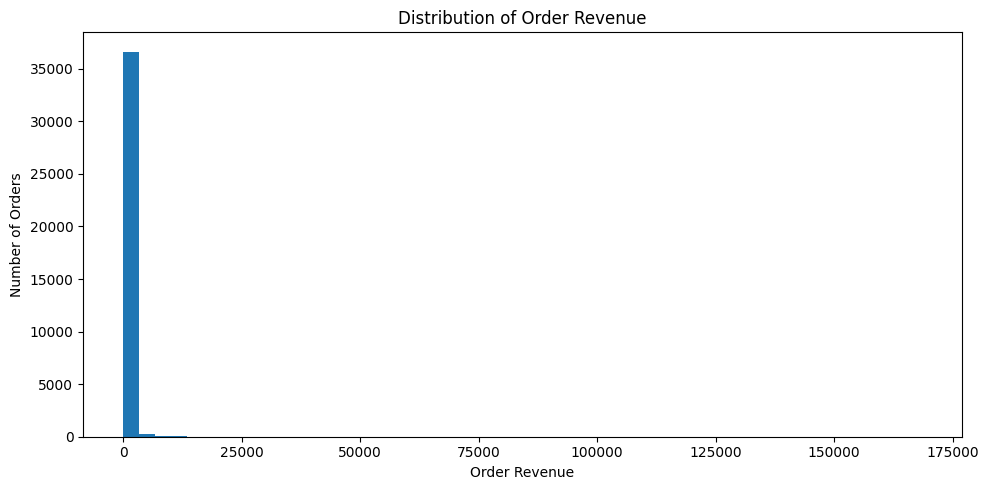

In [77]:
plt.figure(figsize=(10, 5))

plt.hist(
    aov,
    bins=50
)

plt.title("Distribution of Order Revenue")
plt.xlabel("Order Revenue")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [78]:
cancellation_df = df_prepared[
    df_prepared["IsCancellation"]
].copy()

In [79]:
cancellation_df["CancellationValue"] = (
    cancellation_df["Quantity"]
    * cancellation_df["Price"]
)

In [80]:
cancellation_df[
    ["Quantity", "Price", "CancellationValue"]
].describe()

,Quantity,Price,CancellationValue
count,"19,104.00","19,104.00","19,104.00"
mean,-24.96,42.85,-76.53
std,810.41,574.81,"1,463.41"
min,"-80,995.00",0.01,"-168,469.60"
25%,-6.00,1.45,-17.85
50%,-2.00,2.95,-8.95
75%,-1.00,6.65,-3.75
max,1.00,"38,970.00",373.57


In [81]:
customer_invoices = (
    customer_df[
        [
            "Customer ID",
            "Invoice",
            "InvoiceDate"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["Customer ID", "InvoiceDate"]
    )
)

In [82]:
customer_invoices["PurchaseIntervalDays"] = (
    customer_invoices
    .groupby("Customer ID")["InvoiceDate"]
    .diff()
    .dt.total_seconds()
    / (24 * 60 * 60)
)

In [83]:
purchase_intervals = (
    customer_invoices["PurchaseIntervalDays"]
    .dropna()
)

In [84]:
purchase_intervals.describe()

count   31,155.00
mean        51.58
std         75.75
min          0.00
25%          6.97
50%         24.20
75%         61.19
max        714.15
Name: PurchaseIntervalDays, dtype: float64

In [85]:
purchase_intervals.quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
)

0.50    24.20
0.75    61.19
0.90   134.13
0.95   206.04
0.99   368.30
Name: PurchaseIntervalDays, dtype: float64

In [86]:
zero_intervals = (
    purchase_intervals == 0
).sum()

positive_intervals = (
    purchase_intervals > 0
).sum()

print("Same-day intervals:", zero_intervals)
print("Intervals > 0 days:", positive_intervals)

print(
    "Same-day percentage:",
    round(
        zero_intervals /
        len(purchase_intervals) * 100,
        2
    ),
    "%"
)

Same-day intervals: 182
Intervals > 0 days: 30973
Same-day percentage: 0.58 %


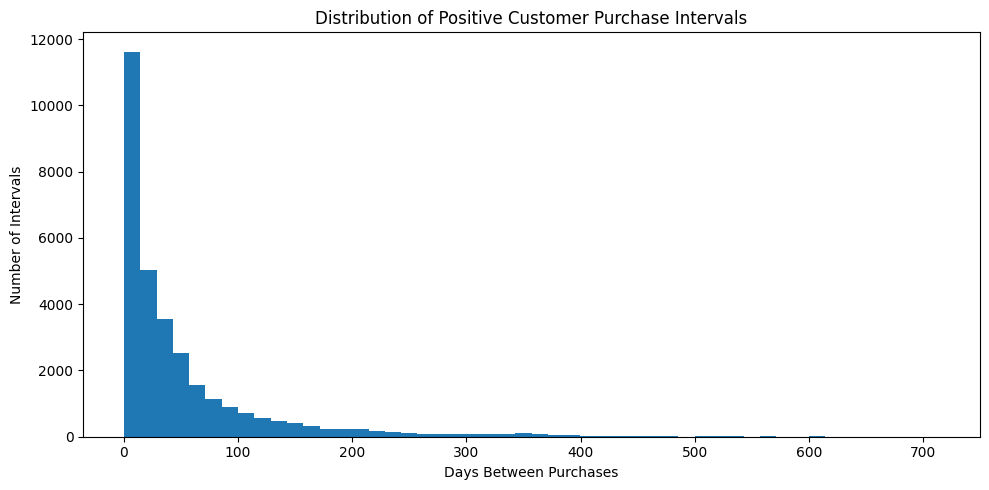

In [87]:
positive_intervals = (
    purchase_intervals[
        purchase_intervals > 0
    ]
)

plt.figure(figsize=(10, 5))

plt.hist(
    positive_intervals,
    bins=50
)

plt.title(
    "Distribution of Positive Customer Purchase Intervals"
)

plt.xlabel("Days Between Purchases")
plt.ylabel("Number of Intervals")

plt.tight_layout()
plt.show()

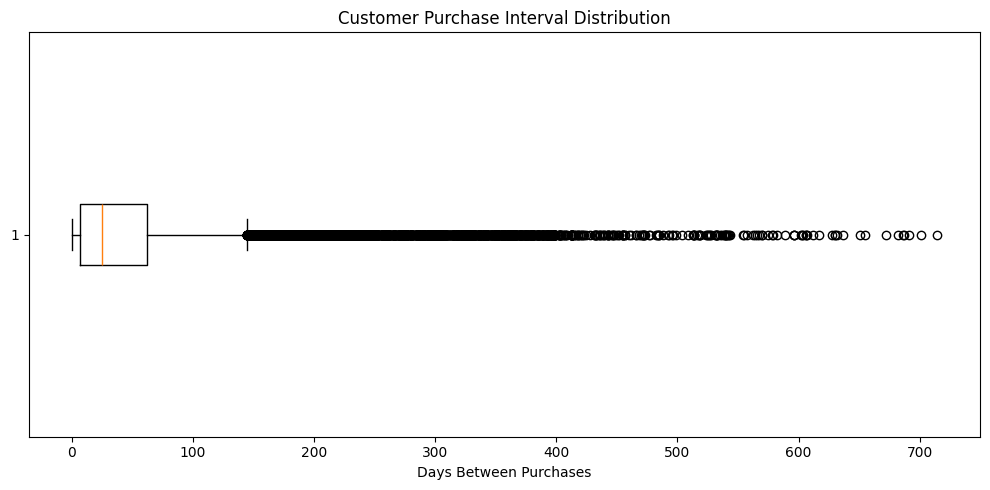

In [88]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    positive_intervals,
    vert=False
)

plt.title(
    "Customer Purchase Interval Distribution"
)

plt.xlabel("Days Between Purchases")

plt.tight_layout()
plt.show()

In [89]:
customer_numeric = customer_summary[
    [
        "Orders",
        "TotalQuantity",
        "TotalRevenue",
        "AverageOrderValue",
        "UniqueProducts"
    ]
]

customer_numeric.corr()

,Orders,TotalQuantity,TotalRevenue,AverageOrderValue,UniqueProducts
Orders,1.00,0.57,0.63,0.03,0.81
TotalQuantity,0.57,1.00,0.87,0.26,0.45
TotalRevenue,0.63,0.87,1.00,0.27,0.48
AverageOrderValue,0.03,0.26,0.27,1.00,0.04
UniqueProducts,0.81,0.45,0.48,0.04,1.00


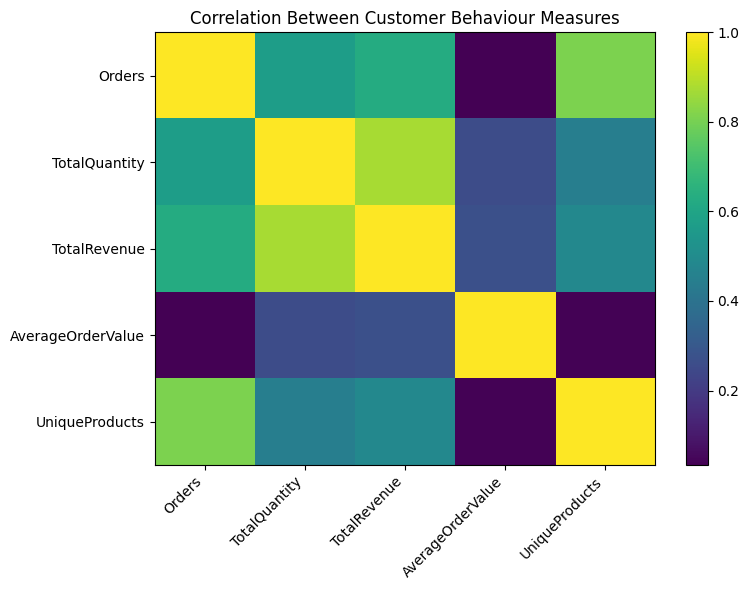

In [90]:
plt.figure(figsize=(8, 6))

plt.imshow(
    customer_numeric.corr(),
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(customer_numeric.columns)),
    customer_numeric.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(customer_numeric.columns)),
    customer_numeric.columns
)

plt.title("Correlation Between Customer Behaviour Measures")

plt.tight_layout()
plt.show()

In [91]:
final_validation = pd.DataFrame({
    "Metric": [
        "Prepared records",
        "Qualifying sales records",
        "Identifiable customers",
        "Unique invoices",
        "Unique products",
        "Countries",
        "Remaining duplicates",
        "Remaining cancellations",
        "Remaining negative quantities",
        "Remaining non-positive prices",
        "Missing dates"
    ],
    "Value": [
        len(df_prepared),
        len(transaction_df),
        transaction_df["Customer ID"].nunique(),
        transaction_df["Invoice"].nunique(),
        transaction_df["StockCode"].nunique(),
        transaction_df["Country"].nunique(),
        transaction_df.duplicated().sum(),
        transaction_df["IsCancellation"].sum(),
        (transaction_df["Quantity"] <= 0).sum(),
        (transaction_df["Price"] <= 0).sum(),
        transaction_df["InvoiceDate"].isna().sum()
    ]
})

final_validation

,Metric,Value
0,Prepared records,1033036
1,Qualifying sales records,1007913
2,Identifiable customers,5878
3,Unique invoices,40077
4,Unique products,4916
5,Countries,43
6,Remaining duplicates,0
7,Remaining cancellations,0
8,Remaining negative quantities,0
9,Remaining non-positive prices,0


In [92]:
transaction_df.to_csv(
    "../data/processed/clean_transactions.csv",
    index=False
)

invoice_df.to_csv(
    "../data/processed/invoice_summary.csv",
    index=False
)

customer_summary.to_csv(
    "../data/processed/customer_summary.csv",
    index=False
)

validation_report.to_csv(
    "../data/processed/data_validation_report.csv",
    index=False
)

# EDA Summary

The exploratory analysis identified several characteristics relevant to the
customer-retention problem.

First, the Online Retail II dataset contains transaction-level information
covering December 2009 to December 2011. The combined dataset contains
1,067,371 records across eight variables, providing sufficient transaction,
customer, product, temporal and geographic information for behavioural
analysis.

The data-quality assessment identified substantial missingness in Customer ID,
with 243,007 records (22.77%) lacking an identifiable customer. Consequently,
customer-level behavioural analysis is restricted to identifiable customers,
while appropriate transaction-level records are retained for other analyses.

The dataset also contains cancellation transactions, negative quantities,
zero-priced records and exact duplicate rows. These characteristics demonstrate
the importance of performing explicit validation and preparation before
calculating customer value or behavioural metrics.

The temporal analysis indicates variation in purchasing activity across months,
days and hours, suggesting that customer behaviour should be examined in its
temporal context rather than treated as uniform.

Customer-level analysis indicates substantial variation in purchasing
frequency and monetary contribution. The distribution of customer orders is
right-skewed, with a relatively small number of customers accounting for a
large number of purchase occasions.

Product and geographic analysis further demonstrates that revenue and demand
are not distributed uniformly across products or countries.

Most importantly for the retention component, customer purchase intervals show
substantial variation. The observed purchase-interval distribution therefore
does not support applying an arbitrary single inactivity threshold without
empirical justification.

These findings provide the basis for the next stage of the project:
customer-level feature engineering, including Recency, Frequency and Monetary
measures, followed by defensible customer segmentation and construction of an
inactivity/at-risk indicator.